In [1]:
import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../src/airsenal/resources/player_attributes_history_2526.csv")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 197106 entries, 0 to 197105
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   timestamp                     197106 non-null  str    
 1   season                        197106 non-null  int64  
 2   gameweek                      197106 non-null  int64  
 3   team                          197106 non-null  str    
 4   position                      197106 non-null  str    
 5   player_id                     197106 non-null  int64  
 6   opta_code                     197106 non-null  str    
 7   player                        197106 non-null  str    
 8   price                         197106 non-null  int64  
 9   selected                      197106 non-null  int64  
 10  transfers_in                  197106 non-null  int64  
 11  transfers_out                 197106 non-null  int64  
 12  transfers_balance             197106 non-null  int64  


,timestamp,season,gameweek,team,position,player_id,opta_code,player,price,selected,transfers_in,transfers_out,transfers_balance,news,chance_of_playing_next_round,return_gameweek
0,2025-09-12T10:17:56.948574,2526,4,ARS,GK,1,p154561,David Raya Martín,55,2683138,616609,304771,311838,NaN,NaN,NaN
1,2025-09-12T10:17:56.948574,2526,4,ARS,GK,2,p109745,Kepa Arrizabalaga Revuelta,44,81660,4256,31043,-26787,NaN,NaN,NaN
2,2025-09-12T10:17:56.948574,2526,4,ARS,GK,3,p463748,Karl Hein,40,58329,5545,20606,-15061,Has joined Werder Bremen on loan for the rest ...,0.0,NaN
3,2025-09-12T10:17:56.948574,2526,4,ARS,GK,4,p551221,Tommy Setford,40,23331,6078,5063,1015,NaN,NaN,NaN
4,2025-09-12T10:17:56.948574,2526,4,ARS,DEF,5,p226597,Gabriel dos Santos Magalhães,61,2484819,633184,347478,285706,NaN,NaN,NaN


In [3]:
df["chance_of_playing_next_round"].value_counts(dropna=False)

chance_of_playing_next_round
NaN      71004
0.0      60743
100.0    57675
75.0      3660
50.0      2209
25.0      1815
Name: count, dtype: int64

In [7]:
from airsenal.db.queries.scores import get_player_scores_df

player_scores = get_player_scores_df("2627", 1)

player_scores = player_scores[
    (player_scores["season"] == "2526") & (player_scores["gameweek"] > 3)
]
len(player_scores)

27640

In [8]:
player_scores["chance_of_playing"] = player_scores["chance_of_playing"].fillna(100)

In [9]:

played_vs_chance = (
    (player_scores["minutes"] >= 60).groupby(player_scores["chance_of_playing"]).mean()
)
played_vs_chance

chance_of_playing
0.0      0.000119
25.0     0.003597
50.0     0.070352
75.0     0.277311
100.0    0.385487
Name: minutes, dtype: float64

In [10]:
played_vs_chance / played_vs_chance[100]

chance_of_playing
0.0      0.000308
25.0     0.009331
50.0     0.182501
75.0     0.719379
100.0    1.000000
Name: minutes, dtype: float64

Text(0, 0.5, '% Played at Least m Minutes\n[Relative to chance of playing 100]')

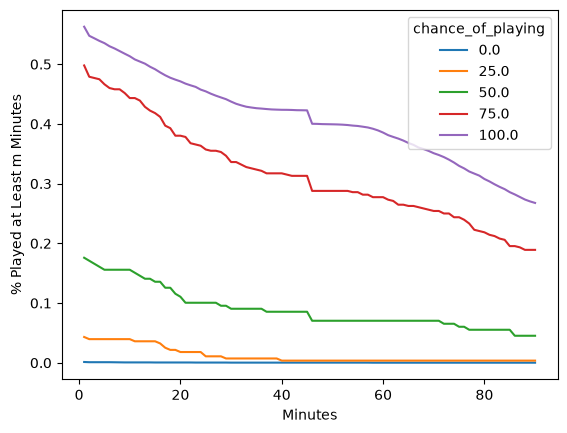

<Figure size 640x480 with 0 Axes>

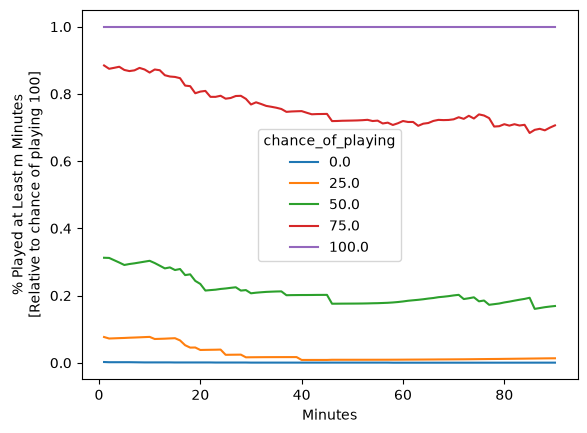

In [11]:
minutes = list(range(1, 91))
chances = []
ratios = []
for m in minutes:
    played_vs_chance = (
        (player_scores["minutes"] >= m).groupby(player_scores["chance_of_playing"]).mean()
    )
    played_vs_chance.name = m
    chances.append(played_vs_chance)
    ratios.append(played_vs_chance / played_vs_chance[100])

chances = pd.concat(chances, axis=1)
ratios = pd.concat(ratios, axis=1)

chances.T.plot()
plt.xlabel("Minutes")
plt.ylabel("% Played at Least m Minutes")

plt.figure()
ratios.T.plot()
plt.xlabel("Minutes")
plt.ylabel("% Played at Least m Minutes\n[Relative to chance of playing 100]")

<Axes: xlabel='minutes', ylabel='Proportion'>

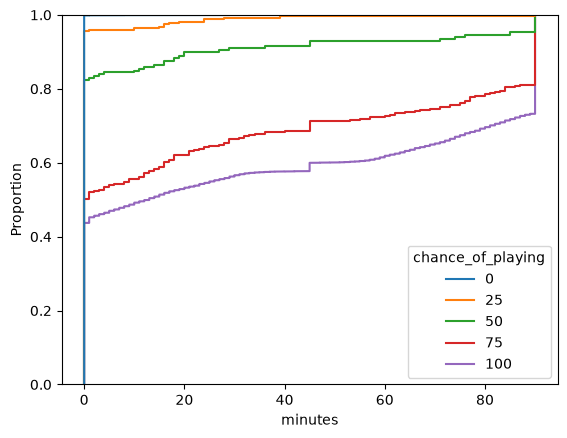

In [12]:
import seaborn as sns

plot_data = player_scores[player_scores["minutes"] >= 0]

sns.ecdfplot(
    data=plot_data,
    x="minutes",
    hue="chance_of_playing",
    hue_order=[0, 25, 50, 75, 100],
    palette="tab10",
)

<Axes: xlabel='minutes', ylabel='Density'>

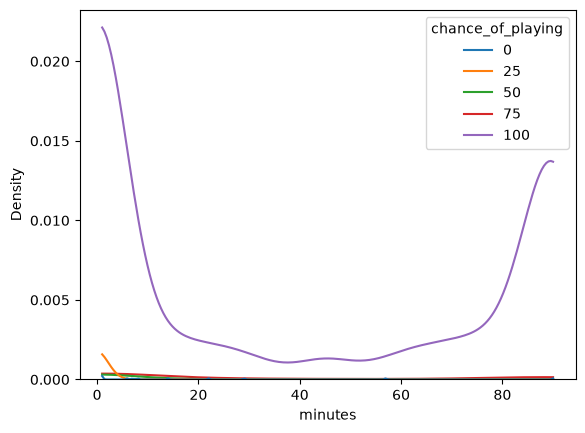

In [13]:

plot_data = player_scores[player_scores["minutes"] >= 0]

sns.kdeplot(
    data=plot_data,
    x="minutes",
    hue="chance_of_playing",
    hue_order=[0, 25, 50, 75, 100],
    palette="tab10",
    clip=(1, 90),
)

In [ ]:
sub = player_scores[
    (player_scores["chance_of_playing"] <= 0) & (player_scores["minutes"] >= 1)
]
sub["player"] = sub["player_id"].apply(lambda x: get_player(x).name)
sub[
    ["player", "gameweek","player_team", "opponent", "minutes", "chance_of_playing", "news"]
].sort_values(
    by=["chance_of_playing", "minutes", "gameweek"],ascending=[True, False, True]
)

,player,gameweek,player_team,opponent,minutes,chance_of_playing,news
78157,Matz Sels,28,NFO,BHA,90,0.0,Groin Injury - Expected back 04 Mar
72548,Hannibal Mejbri,21,BUR,MUN,57,0.0,On international duty at the Africa Cup of Nat...
59882,Luis Guilherme Lira dos Santos,4,WHU,TOT,29,0.0,Shoulder injury - Unknown return date
77398,Richarlison de Andrade,27,TOT,ARS,22,0.0,Hamstring injury - Expected back 01 Mar
72557,Lyle Foster,21,BUR,MUN,14,0.0,On international duty at the Africa Cup of Nat...
75367,Matt O'Riley,25,BHA,CRY,8,0.0,has joined Marseille on loan for the rest of t...
70485,Benjamin White,19,ARS,AVL,7,0.0,Hamstring injury - Expected back 08 Jan
61452,Ross Barkley,7,AVL,BUR,6,0.0,Personal Reasons - Unknown return date
61454,Amadou Onana,7,AVL,BUR,1,0.0,Hamstring injury - Unknown return date
72814,Pedro Cardoso de Lima,21,WOL,EVE,1,0.0,has joined Porto on loan for the rest of the s...


In [22]:
mean_mins = player_scores.groupby("chance_of_playing")["minutes"].mean()
mean_mins / mean_mins[100]

chance_of_playing
0.0      0.000761
25.0     0.029168
50.0     0.219679
75.0     0.770846
100.0    1.000000
Name: minutes, dtype: float64

In [27]:
play = (player_scores["minutes"] >= 1).groupby(player_scores["chance_of_playing"]).mean()
play / play[100]

chance_of_playing
0.0      0.002323
25.0     0.076698
50.0     0.312509
75.0     0.884686
100.0    1.000000
Name: minutes, dtype: float64

In [31]:
play_90 = (player_scores["minutes"] >= 90).groupby(player_scores["chance_of_playing"]).mean()
play_90 / play_90[100]

chance_of_playing
0.0      0.000444
25.0     0.013439
50.0     0.168967
75.0     0.706395
100.0    1.000000
Name: minutes, dtype: float64

In [30]:
play_60 = (player_scores["minutes"] >= 60).groupby(player_scores["chance_of_playing"]).mean()
play_60 / play_60[100]

chance_of_playing
0.0      0.000308
25.0     0.009331
50.0     0.182501
75.0     0.719379
100.0    1.000000
Name: minutes, dtype: float64

In [36]:
for low, high in [(0, 0), (1, 29), (30, 59), (60, 89), (90, 90)]:
    play_m = ((player_scores["minutes"] >= low) & (player_scores["minutes"] <= high)).groupby(player_scores["chance_of_playing"]).mean()
    print(f"Minutes {low} <= m <= {high}:")
    print(play_m)

Minutes 0 <= m <= 0:
chance_of_playing
0.0      0.998693
25.0     0.956835
50.0     0.824121
75.0     0.502101
100.0    0.437202
Name: minutes, dtype: float64
Minutes 1 <= m <= 29:
chance_of_playing
0.0      0.001070
25.0     0.035971
50.0     0.085427
75.0     0.161765
100.0    0.125431
Name: minutes, dtype: float64
Minutes 30 <= m <= 59:
chance_of_playing
0.0      0.000119
25.0     0.003597
50.0     0.020101
75.0     0.058824
100.0    0.051880
Name: minutes, dtype: float64
Minutes 60 <= m <= 89:
chance_of_playing
0.0      0.000000
25.0     0.000000
50.0     0.025126
75.0     0.088235
100.0    0.117824
Name: minutes, dtype: float64
Minutes 90 <= m <= 90:
chance_of_playing
0.0      0.000119
25.0     0.003597
50.0     0.045226
75.0     0.189076
100.0    0.267663
Name: minutes, dtype: float64


In [ ]:
def perc_mins_binned(minutes):
    

In [40]:
player_scores.groupby(["player_id", "chance_of_playing"])["minutes"].describe()

count       mean        std   min    25%   50%  \
player_id chance_of_playing                                                   
1         100.0               35.0  87.428571  15.212777   0.0  90.00  90.0   
2         100.0               35.0   2.571429  15.212777   0.0   0.00   0.0   
3         100.0               35.0   0.000000   0.000000   0.0   0.00   0.0   
4         0.0                  5.0   0.000000   0.000000   0.0   0.00   0.0   
          25.0                 2.0   9.500000  13.435029   0.0   4.75   9.5   
...                            ...        ...        ...   ...    ...   ...   
953       75.0                 1.0   0.000000        NaN   0.0   0.00   0.0   
          100.0               13.0  35.153846  30.599145   0.0   1.00  37.0   
954       100.0               14.0  81.500000  11.765334  59.0  71.50  90.0   
955       100.0                6.0   0.000000   0.000000   0.0   0.00   0.0   
956       100.0                4.0   0.000000   0.000000   0.0   0.00   0.0   

                               75%   max  
player_id chance_of_playing               
1         100.0              90.00  90.0  
2         100.0               0.00  90.0  
3         100.0               0.00   0.0  
4         0.0                 0.00   0.0  
          25.0               14.25  19.0  
...                            ...   ...  
953       75.0                0.00   0.0  
          100.0              60.00  78.0  
954       100.0              90.00  90.0  
955       100.0               0.00   0.0  
956       100.0               0.00   0.0  

[1849 rows x 8 columns]

In [45]:
player_scores["minutes_bin"] = pd.cut(player_scores["minutes"], [0, 1, 30, 60, 90, 91], right=False)
player_scores[["minutes", "minutes_bin"]].head(20)


,minutes,minutes_bin
59188,90,"[90, 91)"
59189,0,"[0, 1)"
59190,0,"[0, 1)"
59191,90,"[90, 91)"
59192,90,"[90, 91)"
59193,0,"[0, 1)"
59194,22,"[1, 30)"
59195,67,"[60, 90)"
59196,0,"[0, 1)"
59197,0,"[0, 1)"


In [71]:
p_min_bins = player_scores.groupby(["player_id", "chance_of_playing"])["minutes_bin"].value_counts(normalize=True)
p_min_bins = p_min_bins.unstack([1, 2]).sort_index(axis=1, ascending=False)
p_min_bins

chance_of_playing     100.0                                            75.0   \
minutes_bin        [90, 91)  [60, 90)  [30, 60)   [1, 30)    [0, 1) [90, 91)   
player_id                                                                      
1                  0.971429  0.000000  0.000000  0.000000  0.028571      NaN   
2                  0.028571  0.000000  0.000000  0.000000  0.971429      NaN   
3                  0.000000  0.000000  0.000000  0.000000  1.000000      NaN   
4                  0.923077  0.038462  0.038462  0.000000  0.000000     1.00   
5                  0.807692  0.038462  0.115385  0.000000  0.038462     0.25   
...                     ...       ...       ...       ...       ...      ...   
952                0.000000  0.000000  0.000000  0.066667  0.933333      NaN   
953                0.000000  0.307692  0.230769  0.384615  0.076923     0.00   
954                0.571429  0.357143  0.071429  0.000000  0.000000      NaN   
955                0.000000  0.000000  0.000000  0.000000  1.000000      NaN   
956                0.000000  0.000000  0.000000  0.000000  1.000000      NaN   

chance_of_playing                                   ...    25.0            \
minutes_bin       [60, 90) [30, 60) [1, 30) [0, 1)  ... [90, 91) [60, 90)   
player_id                                           ...                     
1                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
2                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
3                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
4                     0.00      0.0     0.0    0.0  ...      0.0      0.0   
5                     0.25      0.0     0.0    0.5  ...      0.0      0.0   
...                    ...      ...     ...    ...  ...      ...      ...   
952                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
953                   0.00      0.0     0.0    1.0  ...      NaN      NaN   
954                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
955                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
956                    NaN      NaN     NaN    NaN  ...      NaN      NaN   

chance_of_playing                            0.0                              \
minutes_bin       [30, 60) [1, 30) [0, 1) [90, 91) [60, 90) [30, 60) [1, 30)   
player_id                                                                      
1                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
2                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
3                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
4                      0.0     0.5    0.5      0.0      0.0      0.0     0.0   
5                      0.0     0.0    1.0      0.0      0.0      0.0     0.0   
...                    ...     ...    ...      ...      ...      ...     ...   
952                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
953                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
954                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
955                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
956                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   

chance_of_playing         
minutes_bin       [0, 1)  
player_id                 
1                    NaN  
2                    NaN  
3                    NaN  
4                    1.0  
5                    1.0  
...                  ...  
952                  NaN  
953                  NaN  
954                  NaN  
955                  NaN  
956                  NaN  

[841 rows x 25 columns]

In [73]:
p_min_bins

chance_of_playing     100.0                                            75.0   \
minutes_bin        [90, 91)  [60, 90)  [30, 60)   [1, 30)    [0, 1) [90, 91)   
player_id                                                                      
1                  0.971429  0.000000  0.000000  0.000000  0.028571      NaN   
2                  0.028571  0.000000  0.000000  0.000000  0.971429      NaN   
3                  0.000000  0.000000  0.000000  0.000000  1.000000      NaN   
4                  0.923077  0.038462  0.038462  0.000000  0.000000     1.00   
5                  0.807692  0.038462  0.115385  0.000000  0.038462     0.25   
...                     ...       ...       ...       ...       ...      ...   
952                0.000000  0.000000  0.000000  0.066667  0.933333      NaN   
953                0.000000  0.307692  0.230769  0.384615  0.076923     0.00   
954                0.571429  0.357143  0.071429  0.000000  0.000000      NaN   
955                0.000000  0.000000  0.000000  0.000000  1.000000      NaN   
956                0.000000  0.000000  0.000000  0.000000  1.000000      NaN   

chance_of_playing                                   ...    25.0            \
minutes_bin       [60, 90) [30, 60) [1, 30) [0, 1)  ... [90, 91) [60, 90)   
player_id                                           ...                     
1                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
2                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
3                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
4                     0.00      0.0     0.0    0.0  ...      0.0      0.0   
5                     0.25      0.0     0.0    0.5  ...      0.0      0.0   
...                    ...      ...     ...    ...  ...      ...      ...   
952                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
953                   0.00      0.0     0.0    1.0  ...      NaN      NaN   
954                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
955                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
956                    NaN      NaN     NaN    NaN  ...      NaN      NaN   

chance_of_playing                            0.0                              \
minutes_bin       [30, 60) [1, 30) [0, 1) [90, 91) [60, 90) [30, 60) [1, 30)   
player_id                                                                      
1                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
2                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
3                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
4                      0.0     0.5    0.5      0.0      0.0      0.0     0.0   
5                      0.0     0.0    1.0      0.0      0.0      0.0     0.0   
...                    ...     ...    ...      ...      ...      ...     ...   
952                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
953                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
954                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
955                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
956                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   

chance_of_playing         
minutes_bin       [0, 1)  
player_id                 
1                    NaN  
2                    NaN  
3                    NaN  
4                    1.0  
5                    1.0  
...                  ...  
952                  NaN  
953                  NaN  
954                  NaN  
955                  NaN  
956                  NaN  

[841 rows x 25 columns]

<Axes: xlabel='chance_of_playing,minutes_bin'>

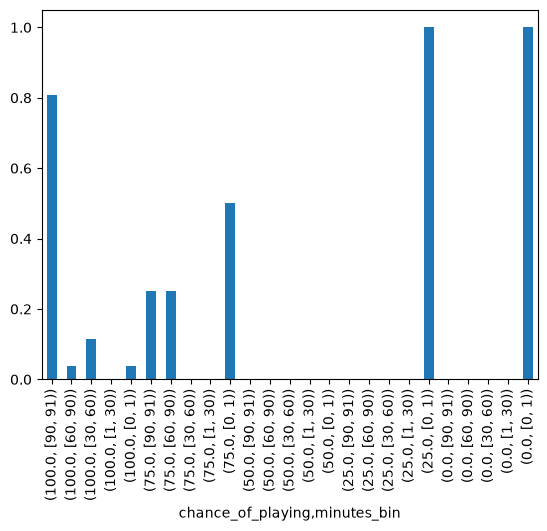

In [75]:
p_min_bins.loc[5].plot.bar()

chance_of_playing     100.0                                            75.0   \
minutes_bin        [90, 91)  [60, 90)  [30, 60)   [1, 30)    [0, 1) [90, 91)   
player_id                                                                      
1                  0.971429  0.000000  0.000000  0.000000  0.028571      NaN   
2                  0.028571  0.000000  0.000000  0.000000  0.971429      NaN   
3                  0.000000  0.000000  0.000000  0.000000  1.000000      NaN   
4                  0.923077  0.038462  0.038462  0.000000  0.000000     1.00   
5                  0.807692  0.038462  0.115385  0.000000  0.038462     0.25   
...                     ...       ...       ...       ...       ...      ...   
952                0.000000  0.000000  0.000000  0.066667  0.933333      NaN   
953                0.000000  0.307692  0.230769  0.384615  0.076923     0.00   
954                0.571429  0.357143  0.071429  0.000000  0.000000      NaN   
955                0.000000  0.000000  0.000000  0.000000  1.000000      NaN   
956                0.000000  0.000000  0.000000  0.000000  1.000000      NaN   

chance_of_playing                                   ...    25.0            \
minutes_bin       [60, 90) [30, 60) [1, 30) [0, 1)  ... [90, 91) [60, 90)   
player_id                                           ...                     
1                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
2                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
3                      NaN      NaN     NaN    NaN  ...      NaN      NaN   
4                     0.00      0.0     0.0    0.0  ...      0.0      0.0   
5                     0.25      0.0     0.0    0.5  ...      0.0      0.0   
...                    ...      ...     ...    ...  ...      ...      ...   
952                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
953                   0.00      0.0     0.0    1.0  ...      NaN      NaN   
954                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
955                    NaN      NaN     NaN    NaN  ...      NaN      NaN   
956                    NaN      NaN     NaN    NaN  ...      NaN      NaN   

chance_of_playing                            0.0                              \
minutes_bin       [30, 60) [1, 30) [0, 1) [90, 91) [60, 90) [30, 60) [1, 30)   
player_id                                                                      
1                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
2                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
3                      NaN     NaN    NaN      NaN      NaN      NaN     NaN   
4                      0.0     0.5    0.5      0.0      0.0      0.0     0.0   
5                      0.0     0.0    1.0      0.0      0.0      0.0     0.0   
...                    ...     ...    ...      ...      ...      ...     ...   
952                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
953                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
954                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
955                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   
956                    NaN     NaN    NaN      NaN      NaN      NaN     NaN   

chance_of_playing         
minutes_bin       [0, 1)  
player_id                 
1                    NaN  
2                    NaN  
3                    NaN  
4                    1.0  
5                    1.0  
...                  ...  
952                  NaN  
953                  NaN  
954                  NaN  
955                  NaN  
956                  NaN  

[841 rows x 25 columns]

In [70]:
p_min_bins.unstack([1, 2]).sort_index(axis=1, ascending=False)[[100, 75]].dropna()

chance_of_playing     100.0                                             75.0   \
minutes_bin        [90, 91)  [60, 90)  [30, 60)   [1, 30)    [0, 1)  [90, 91)   
player_id                                                                       
4                  0.923077  0.038462  0.038462  0.000000  0.000000  1.000000   
5                  0.807692  0.038462  0.115385  0.000000  0.038462  0.250000   
6                  0.800000  0.000000  0.066667  0.000000  0.133333  0.400000   
8                  0.240000  0.320000  0.120000  0.160000  0.160000  0.166667   
9                  0.482759  0.103448  0.034483  0.172414  0.206897  0.333333   
...                     ...       ...       ...       ...       ...       ...   
929                0.038462  0.384615  0.115385  0.346154  0.115385  0.000000   
930                0.000000  0.052632  0.052632  0.210526  0.684211  0.000000   
934                0.000000  0.000000  0.000000  0.066667  0.933333  0.000000   
945                0.689655  0.206897  0.034483  0.000000  0.068966  0.333333   
953                0.000000  0.307692  0.230769  0.384615  0.076923  0.000000   

chance_of_playing                                          
minutes_bin        [60, 90)  [30, 60)   [1, 30)    [0, 1)  
player_id                                                  
4                  0.000000  0.000000  0.000000  0.000000  
5                  0.250000  0.000000  0.000000  0.500000  
6                  0.000000  0.000000  0.000000  0.600000  
8                  0.166667  0.000000  0.000000  0.666667  
9                  0.000000  0.333333  0.000000  0.333333  
...                     ...       ...       ...       ...  
929                0.000000  0.000000  0.000000  1.000000  
930                0.000000  1.000000  0.000000  0.000000  
934                0.000000  0.000000  0.333333  0.666667  
945                0.000000  0.000000  0.000000  0.666667  
953                0.000000  0.000000  0.000000  1.000000  

[262 rows x 10 columns]

In [ ]:
p_min_bins.unstack([1, 2]).sort_index(axis=1, ascending=False)[[100, 75]].dropna()